# Day 1｜AI 全域市場需求預測與動態商情分析

## 從市場訊號到可驗證需求預測

> **資料使用邊界：** 本 Notebook 使用固定亂數種子產生的教學虛擬資料，不是任何企業的真實營運資料。結果只能用於練習分析流程，不可宣稱為企業事實或因果效果。

### 故事情境

週一早上，四家企業同時收到一封主管來信：雜草町想知道哪種手作課值得加開；義大要判斷哪種度假套票有成長機會；盛香珍要選出下一個小泡芙主打方向；寶島眼鏡要看哪種商品／服務需求正在升溫。主管沒有給答案，只交付兩年虛擬市場訊號，要求今天下班前提出『先做哪一項、預測誤差多大、還要補什麼資料』。

### 今日決策問題

**哪一個商品或服務值得優先驗證需求，而且證據與預測誤差是否足以支持下一步？**

### 學習目標

- 能區分描述、預測與因果問題
- 能完成資料品質檢查與市場趨勢視覺化
- 能以時間先後切分資料建立可解釋 baseline
- 能用 MAE、RMSE、R² 解讀預測表現
- 能把結果翻譯成含限制的企業決策

### Colab 操作提醒

1. 在 Google Drive 建立個人副本。
2. 將對應 CSV 上傳到 Colab `/content`，或保持教材包原始相對路徑。
3. 由上到下依序執行；若 Runtime 重啟，請重新執行全部儲存格。
4. 每個程式碼儲存格後都有繁體中文說明、預期輸出與完成檢核。

> **明志科技大學 M4｜寶島眼鏡 專屬 Notebook**
>
> 教學設計與教材製作｜恩恩統計家教
>
> www.enentutor.com

#### 第一次使用 Google Colab

1. 登入 Google 帳號後，選擇「檔案 → 在雲端硬碟中儲存副本」。
2. 依頁面順序按儲存格左側播放鍵；也可按 `Shift+Enter` 執行目前儲存格。
3. 星號表示正在執行，綠色勾選表示完成；看到紅字時先讀最末一行。
4. 若執行順序混亂，選擇「執行階段 → 重新啟動工作階段並全部執行」。
5. 本 Notebook 已綁定 寶島眼鏡，不需修改企業名稱；Raw 失敗時才上傳同企業 CSV 到 `/content`。

### [D1-S01] 載入資料並確認分析任務

In [1]:
# 本格目的：載入套件並找到教學資料檔
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# 中文圖表字型設定（Windows／macOS／Linux／Google Colab）
import hashlib
import os
import sys
from pathlib import Path
from urllib.request import urlretrieve
import matplotlib as mpl
from matplotlib import font_manager
from matplotlib.ft2font import FT2Font

FONT_URL = "https://raw.githubusercontent.com/notofonts/noto-cjk/f8d157532fbfaeda587e826d4cd5b21a49186f7c/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
FONT_SHA256 = "dce08bd4fd91aa8aa76ed8fea4b694c2dfb8550f67871e326843212ddbeb88b4"
font_override = os.environ.get("M4_FONT_PATH")
FONT_FILE_CANDIDATES = [
    *([Path(font_override)] if font_override else []),
    Path("C:/Windows/Fonts/msjh.ttc"),
    Path("C:/Windows/Fonts/msjhbd.ttc"),
    Path("/usr/share/fonts/opentype/noto/NotoSansCJKtc-Regular.otf"),
    Path("/usr/share/fonts/truetype/noto/NotoSansTC-Regular.ttf"),
    Path("/usr/local/share/fonts/NotoSansTC-Regular.ttf"),
    Path("/System/Library/Fonts/PingFang.ttc"),
]

font_path = next((path for path in FONT_FILE_CANDIDATES if path.is_file()), None)
in_colab = (
    "google.colab" in sys.modules
    or "COLAB_RELEASE_TAG" in os.environ
    or "COLAB_BACKEND_VERSION" in os.environ
    or Path("/content").is_dir()
)
allow_download = in_colab or os.environ.get("M4_DOWNLOAD_CJK_FONT") == "1"
if font_path is None and allow_download:
    font_cache = Path("/content/.cache/m4-fonts") if in_colab else Path.home() / ".cache" / "m4-fonts"
    font_cache.mkdir(parents=True, exist_ok=True)
    downloaded_font = font_cache / "NotoSansCJKtc-Regular.otf"
    if downloaded_font.is_file() and hashlib.sha256(downloaded_font.read_bytes()).hexdigest() != FONT_SHA256:
        downloaded_font.unlink()
    if not downloaded_font.is_file():
        temporary_font = downloaded_font.with_suffix(".download")
        temporary_font.unlink(missing_ok=True)
        try:
            urlretrieve(FONT_URL, temporary_font)
        except (OSError, ValueError) as exc:
            temporary_font.unlink(missing_ok=True)
            raise RuntimeError("無法下載免費的 Noto Sans TC 字型，請確認網路後重新執行本格。") from exc
        if hashlib.sha256(temporary_font.read_bytes()).hexdigest() != FONT_SHA256:
            temporary_font.unlink(missing_ok=True)
            raise RuntimeError("下載的 Noto Sans TC 字型檔驗證失敗，請重新執行本格。")
        temporary_font.replace(downloaded_font)
    font_path = downloaded_font

if font_path is None:
    raise RuntimeError(
        "找不到可顯示繁體中文的字型；本機請安裝免費的 Noto Sans TC，"
        "或設定 M4_FONT_PATH 指向字型檔。"
    )

font_path = font_path.resolve()
try:
    # 使用公開 API，把實際字型檔加入「目前這次執行」的 FontManager。
    font_manager.fontManager.addfont(str(font_path))
except (OSError, RuntimeError) as exc:
    raise RuntimeError(f"Matplotlib 無法載入中文字型檔：{font_path}") from exc

registered_font = next(
    (
        entry
        for entry in reversed(font_manager.fontManager.ttflist)
        if Path(entry.fname).resolve() == font_path
    ),
    None,
)
if registered_font is None:
    raise RuntimeError(f"中文字型未成功註冊到目前的 Matplotlib：{font_path}")
font_name = registered_font.name

font_rc = {
    "font.family": font_name,
    "font.sans-serif": [font_name],
    "axes.unicode_minus": False,
}
sns.set_theme(style="whitegrid", rc=font_rc)
mpl.rcParams.update(font_rc)

# 驗證 Matplotlib 真的能用已註冊的名稱找到字型，而且含課程常用繁中文字元。
try:
    resolved_font = font_manager.findfont(
        font_manager.FontProperties(family=[font_name]),
        fallback_to_default=False,
    )
except ValueError as exc:
    raise RuntimeError(f"Matplotlib 找不到剛註冊的中文字型：{font_name}") from exc
font_face = FT2Font(resolved_font)
required_text = "繁體中文圖表標題座標軸月份需求價格廣告預測實際值"
missing_glyphs = sorted(
    {char for char in required_text if font_face.get_char_index(ord(char)) == 0}
)
if missing_glyphs:
    raise RuntimeError(f"中文字型缺少必要字元：{missing_glyphs}")

# Plotly 若已安裝，同步設定預設範本；未安裝時不增加課堂錯誤。
try:
    import plotly.io as pio

    pio.templates.default = "plotly_white"
    pio.templates["plotly_white"].layout.font.family = f'"{font_name}", sans-serif'
except (ImportError, KeyError, AttributeError):
    pass
print(f"圖表中文字型：{font_name}（{resolved_font}）")

# 優先從公開 GitHub Raw 讀取企業專屬資料；失敗時再依序尋找 /content 與本機相對路徑
import os

ENTERPRISE_ID = "formosa-optical"
ENTERPRISE_NAME = "寶島眼鏡"
ENTERPRISE_DISPLAY_NAME = "寶島眼鏡"
RAW_DATA_URL = "https://raw.githubusercontent.com/johnnychao/mcut-m4-business-analytics-2026-student/main/docs/resources/data/formosa-optical/day-1-formosa-optical-market-demand.csv"
DATA_FILENAME = "day-1-formosa-optical-market-demand.csv"
FORCE_LOCAL_DATA = os.environ.get("M4_FORCE_LOCAL_DATA") == "1"

try:
    # 正式教材 QA 可關閉遠端來源，確認企業專屬本機資料能獨立運作
    if FORCE_LOCAL_DATA:
        raise ConnectionError("M4 Notebook QA：改用本機資料備援")
    df = pd.read_csv(RAW_DATA_URL)
    data_source = RAW_DATA_URL
except Exception as remote_error:
    candidate_paths = [
        Path("/content") / DATA_FILENAME,
        Path(DATA_FILENAME),
        Path("../04_data") / ENTERPRISE_ID / DATA_FILENAME,
        Path("../../04_data") / ENTERPRISE_ID / DATA_FILENAME,
    ]
    data_path = next((path for path in candidate_paths if path.exists()), None)
    if data_path is None:
        raise FileNotFoundError(
            f"GitHub Raw 暫時無法讀取，而且 /content 與本機相對路徑都找不到 {DATA_FILENAME}。"
        ) from remote_error
    df = pd.read_csv(data_path)
    data_source = str(data_path)

# 企業專屬 CSV 應只有一家公司；若不一致就立即停止，避免跨企業混算
if df["company"].nunique() != 1 or str(df["company"].iloc[0]) != ENTERPRISE_NAME:
    raise ValueError(f"資料企業不符：預期 {ENTERPRISE_NAME}，實際 {df['company'].unique().tolist()}")

# 所有課堂匯出檔依企業集中，避免 16 本 Notebook 的輸出互相覆蓋
OUTPUT_DIR = Path("outputs") / ENTERPRISE_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"企業情境：{ENTERPRISE_DISPLAY_NAME}")
print(f"資料來源：{data_source}")
print(f"資料尺寸：{df.shape}")
display(df.head(3))

圖表中文字型：Microsoft JhengHei
企業情境：寶島眼鏡
資料來源：..\04_data\formosa-optical\day-1-formosa-optical-market-demand.csv
資料尺寸：(96, 12)


,date,company,offer,search_index,social_mentions,website_visits,promo_spend,price_index,competitor_index,holiday_flag,demand_units,is_synthetic
0,2024-01-01,寶島眼鏡,日常鏡框,43.500,74.000,"2,098.000","8,561.000",0.895,57.900,1,377,True
1,2024-02-01,寶島眼鏡,日常鏡框,52.200,108.000,"2,121.000","9,546.000",1.019,42.500,1,447,True
2,2024-03-01,寶島眼鏡,日常鏡框,47.700,70.000,"2,049.000","6,822.000",0.993,29.300,0,374,True


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 載入常用分析套件，依序尋找 Colab 或教材包中的 CSV，並預覽前三列。
- **預期輸出：** 顯示資料路徑、資料尺寸與三筆資料。
- **完成檢核：** `is_synthetic` 欄位存在，而且所有值均為 True。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S02] 檢查日期、缺失與重複主鍵

In [2]:
# 本格目的：確認資料邊界、型態、缺失與重複狀況
assert "is_synthetic" in df.columns, "缺少虛擬資料標記欄位"
assert df["is_synthetic"].astype(str).str.lower().eq("true").all(), "資料中出現非虛擬標記"

df["date"] = pd.to_datetime(df["date"], errors="coerce")
quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False),
})
duplicate_count = df.duplicated(subset=["date", "company", "offer"]).sum()
print(f"日期範圍：{df['date'].min().date()} 到 {df['date'].max().date()}")
print(f"重複主鍵筆數：{duplicate_count}")
display(quality_report)

# 建模前只補數值特徵缺失；目標 demand_units 不可隨意補造
for col in ["social_mentions", "website_visits"]:
    df[col] = df.groupby("company")[col].transform(lambda s: s.fillna(s.median()))

日期範圍：2024-01-01 到 2025-12-01
重複主鍵筆數：0


,dtype,missing,unique
date,datetime64[ns],0,24
company,object,0,1
offer,object,0,4
search_index,float64,0,86
social_mentions,float64,1,65
website_visits,float64,0,90
promo_spend,float64,0,95
price_index,float64,0,80
competitor_index,float64,0,86
holiday_flag,int64,0,2


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 確認日期、缺失、唯一值與重複主鍵，再以企業中位數處理兩個教學用缺失欄位。
- **預期輸出：** 品質表中可看到原始缺失；補值後兩欄缺失為 0。
- **完成檢核：** `duplicate_count` 為 0，且 `demand_units` 沒有缺值。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S03] 確認綁定企業並建立描述統計

In [3]:
# 本格目的：只分析一家公司，避免把不同量級混在同一模型
# 本 Notebook 已由網站企業卡片綁定唯一企業，不需再次選擇
company_df = df.copy()
assert not company_df.empty, "企業名稱不正確，請從可選企業清單複製"
assert company_df["company"].nunique() == 1

offer_summary = company_df.groupby("offer").agg(
    months=("date", "nunique"),
    mean_demand=("demand_units", "mean"),
    demand_std=("demand_units", "std"),
    mean_search=("search_index", "mean"),
    total_promo=("promo_spend", "sum"),
).sort_values("mean_demand", ascending=False)
display(offer_summary.round(2))

,months,mean_demand,demand_std,mean_search,total_promo
offer,,,,,
智慧門市會員方案,24,442.790,25.740,70.870,"189,884.000"
親子視覺健康,24,426.790,31.060,65.450,"182,775.000"
機能鏡片,24,403.120,40.440,58.680,"184,395.000"
日常鏡框,24,377.960,32.090,51.400,"184,172.000"


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 修改一個參數即可切換企業，並比較各商品／服務的平均需求、波動與市場訊號。
- **預期輸出：** 四個商品／服務的摘要表。
- **完成檢核：** 表格只有一家企業，且每個 offer 都有 24 個月份。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S04] 畫出月需求與三月移動平均

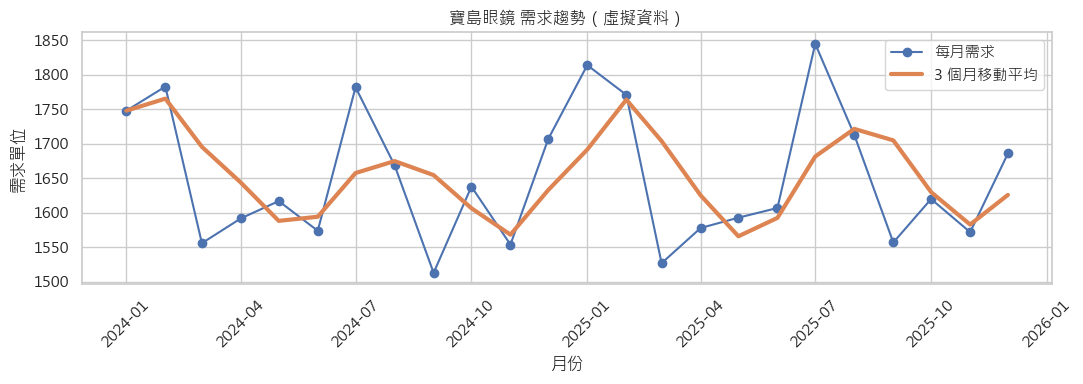

,date,demand_units,search_index,website_visits,demand_ma3
18,2025-07-01,1845,68.700,"10,150.000","1,681.700"
19,2025-08-01,1713,69.700,"10,068.000","1,721.700"
20,2025-09-01,1557,56.400,"8,560.000","1,705.000"
21,2025-10-01,1620,56.200,"9,050.000","1,630.000"
22,2025-11-01,1572,58.500,"8,415.000","1,583.000"
23,2025-12-01,1686,71.700,"9,866.000","1,626.000"


In [4]:
# 本格目的：先觀察時間趨勢，再決定是否需要預測模型
monthly = company_df.groupby("date", as_index=False).agg(
    demand_units=("demand_units", "sum"),
    search_index=("search_index", "mean"),
    website_visits=("website_visits", "sum"),
)
monthly = monthly.sort_values("date")
monthly["demand_ma3"] = monthly["demand_units"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly["date"], monthly["demand_units"], marker="o", label="每月需求")
ax.plot(monthly["date"], monthly["demand_ma3"], linewidth=3, label="3 個月移動平均")
ax.set(title=f"{ENTERPRISE_NAME} 需求趨勢（虛擬資料）", xlabel="月份", ylabel="需求單位")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(monthly.tail(6).round(1))

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 將企業各商品需求加總成月總量，並用三月移動平均降低短期噪音。
- **預期輸出：** 一張需求趨勢圖及最近六個月表格。
- **完成檢核：** 日期依序排列；圖表不能被解讀成任何真實企業趨勢。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S05] 檢查數值關聯並守住因果邊界

,correlation
demand_units,1.000
social_mentions,0.594
website_visits,0.581
search_index,0.554
holiday_flag,0.529
promo_spend,0.466
price_index,0.439
competitor_index,-0.141


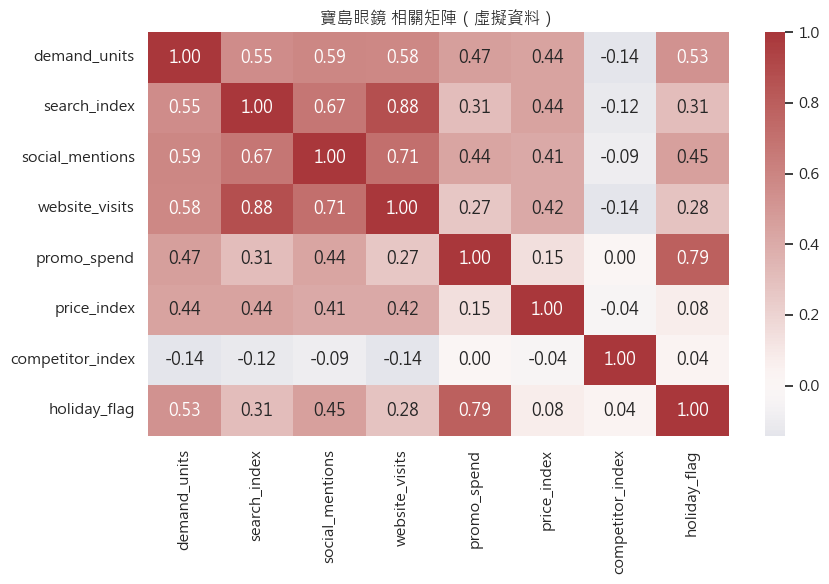

固定句型：在此虛擬資料中，部分市場訊號與需求呈關聯；這不表示訊號造成需求改變。


In [5]:
# 本格目的：找出與需求共同變動的市場訊號，但不做因果宣稱
numeric_cols = [
    "demand_units", "search_index", "social_mentions", "website_visits",
    "promo_spend", "price_index", "competitor_index", "holiday_flag",
]
corr = company_df[numeric_cols].corr()
display(corr["demand_units"].sort_values(ascending=False).to_frame("correlation"))

plt.figure(figsize=(9, 6))
sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title(f"{ENTERPRISE_NAME} 相關矩陣（虛擬資料）")
plt.tight_layout()
plt.show()

print("固定句型：在此虛擬資料中，部分市場訊號與需求呈關聯；這不表示訊號造成需求改變。")

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 計算數值欄位相關係數並用熱圖呈現；相關只用於探索。
- **預期輸出：** 需求相關排序與相關矩陣。
- **完成檢核：** 口頭與書面結論均使用『呈關聯』，不得寫『造成』。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S06] 建立時間切分與 naive baseline

In [6]:
# 本格目的：用較早資料訓練、較晚資料測試，避免提前看見未來
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_df = company_df.sort_values(["date", "offer"]).copy()
model_df["naive_prediction"] = model_df.groupby("offer")["demand_units"].shift(1)
unique_dates = np.array(sorted(model_df["date"].dropna().unique()))
cutoff_date = unique_dates[int(len(unique_dates) * 0.80)]
train_df = model_df.loc[model_df["date"] < cutoff_date].copy()
test_df = model_df.loc[model_df["date"] >= cutoff_date].dropna(subset=["naive_prediction"]).copy()

naive_mae = mean_absolute_error(test_df["demand_units"], test_df["naive_prediction"])
print(f"切分日期：{pd.Timestamp(cutoff_date).date()}")
print(f"訓練筆數：{len(train_df)}；測試筆數：{len(test_df)}")
print(f"Naive baseline MAE：{naive_mae:,.2f} 需求單位")

切分日期：2025-08-01
訓練筆數：76；測試筆數：20
Naive baseline MAE：28.65 需求單位


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 依時間先後切分資料，並以『同商品上月需求』作為簡單基準。
- **預期輸出：** 切分日期、訓練／測試筆數與 baseline MAE。
- **完成檢核：** 訓練日期全部早於測試日期；沒有隨機打散時間。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S07] 建立可重現的線性迴歸 Pipeline

In [7]:
# 本格目的：把數值與商品類別放入同一個可重現預測流程
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "search_index", "social_mentions", "website_visits", "promo_spend",
    "price_index", "competitor_index", "holiday_flag",
]
categorical_features = ["offer"]
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
model = Pipeline([("preprocess", preprocess), ("model", LinearRegression())])

X_train = train_df[numeric_features + categorical_features]
y_train = train_df["demand_units"]
X_test = test_df[numeric_features + categorical_features]
y_test = test_df["demand_units"]
model.fit(X_train, y_train)
test_df["model_prediction"] = np.maximum(0, model.predict(X_test))
print("模型已完成訓練。")

模型已完成訓練。


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 在 Pipeline 內完成補值、標準化、類別編碼與線性迴歸；測試資料不參與 fit。
- **預期輸出：** 顯示模型完成訓練，並在測試資料新增預測欄。
- **完成檢核：** 特徵清單沒有 `demand_units` 的未來值或任何測試答案。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S08] 比較 baseline 與線性迴歸

,model,MAE,RMSE,R2
0,Naive: previous month,28.650,34.517,-0.382
1,Linear regression,19.916,24.233,0.319


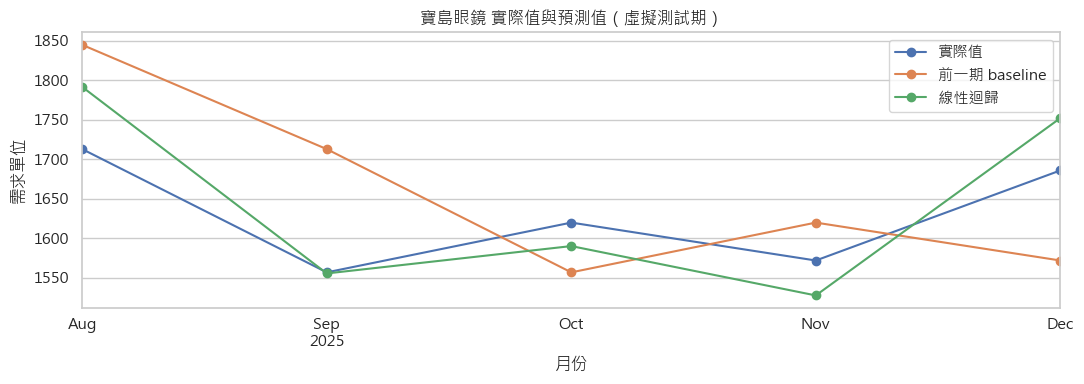

In [8]:
# 本格目的：用測試資料的 MAE、RMSE、R² 判斷模型是否值得採用
def regression_metrics(actual, predicted, name):
    return {
        "model": name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }

metrics = pd.DataFrame([
    regression_metrics(y_test, test_df["naive_prediction"], "Naive: previous month"),
    regression_metrics(y_test, test_df["model_prediction"], "Linear regression"),
])
display(metrics.round(3))

plot_df = test_df.groupby("date", as_index=False).agg(
    actual=("demand_units", "sum"),
    naive=("naive_prediction", "sum"),
    model=("model_prediction", "sum"),
)
plot_df.plot(x="date", y=["actual", "naive", "model"], figsize=(11, 4), marker="o")
plt.title(f"{ENTERPRISE_NAME} 實際值與預測值（虛擬測試期）")
plt.xlabel("月份")
plt.legend(["實際值", "前一期 baseline", "線性迴歸"] )
plt.ylabel("需求單位")
plt.tight_layout()
plt.show()

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 以相同測試集比較簡單基準和線性迴歸，並將各商品預測加總成月圖。
- **預期輸出：** 兩列模型指標與實際／預測折線圖。
- **完成檢核：** 若線性迴歸 MAE 較高，結論應是目前不值得取代簡單基準。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S09] 執行透明的市場訊號情境模擬

In [9]:
# 本格目的：只改變一個可見假設，觀察模型預測如何改變
latest = company_df.sort_values("date").groupby("offer", as_index=False).tail(1).copy()
base_pred = np.maximum(0, model.predict(latest[numeric_features + categorical_features]))
scenario = latest.copy()
scenario["search_index"] = np.minimum(100, scenario["search_index"] * 1.10)
scenario_pred = np.maximum(0, model.predict(scenario[numeric_features + categorical_features]))

scenario_result = latest[["offer", "search_index"]].copy()
scenario_result["base_prediction"] = base_pred
scenario_result["search_plus_10pct_prediction"] = scenario_pred
scenario_result["prediction_change"] = scenario_pred - base_pred
scenario_result["warning"] = "虛擬關聯情境；不是因果效果"
display(scenario_result.round(2))

,offer,search_index,base_prediction,search_plus_10pct_prediction,prediction_change,warning
47,機能鏡片,63.000,419.740,413.770,-5.970,虛擬關聯情境；不是因果效果
23,日常鏡框,63.900,402.920,396.860,-6.060,虛擬關聯情境；不是因果效果
71,親子視覺健康,78.500,461.330,453.890,-7.440,虛擬關聯情境；不是因果效果
95,智慧門市會員方案,81.500,468.250,460.530,-7.730,虛擬關聯情境；不是因果效果


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 把搜尋指數提高 10% 作為透明情境，保持其他欄位不變後比較預測。
- **預期輸出：** 每個商品的基準與情境預測差。
- **完成檢核：** 表格保留非因果警語；不得說提高搜尋一定會帶來同幅需求。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S10] 整理需求預測成果草稿與繳交前檢核

In [10]:
# 本格目的：把分析結果整理成可交付、可追溯的短表
best_model_row = metrics.sort_values("MAE").iloc[0]
decision_card = pd.DataFrame({
    "item": ["企業", "較佳測試方法", "測試 MAE", "建議行動", "限制", "下一步資料"],
    "content": [
        ENTERPRISE_NAME,
        best_model_row["model"],
        f"{best_model_row['MAE']:.2f} 需求單位",
        "先以小規模測試驗證需求，不直接依虛擬預測大量備貨／排班。",
        "資料為虛擬且僅呈現關聯；未納入真實容量、價格實驗與競爭事件。",
        "取得至少 12 個月真實銷售／報名、價格、促銷與缺貨紀錄後回測。",
    ],
})
display(decision_card)
decision_card.to_csv(OUTPUT_DIR / "Day1_需求決策卡.csv", index=False, encoding="utf-8-sig")

,item,content
0,企業,寶島眼鏡
1,較佳測試方法,Linear regression
2,測試 MAE,19.92 需求單位
3,建議行動,先以小規模測試驗證需求，不直接依虛擬預測大量備貨／排班。
4,限制,資料為虛擬且僅呈現關聯；未納入真實容量、價格實驗與競爭事件。
5,下一步資料,取得至少 12 個月真實銷售／報名、價格、促銷與缺貨紀錄後回測。


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 自動帶入較低 MAE 的方法，建立包含行動、限制與下一步資料的決策卡。
- **預期輸出：** 六列決策卡並輸出 CSV。
- **完成檢核：** 建議未把虛擬資料描述成企業真實事實。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

## 當日學習驗收

正式作答請由課程網站進入當日 Google Form。本區只供你先確認題意與個人繳交內容，請勿在 Notebook 尋找或記錄正確選項。

### 10 題選擇題

#### 第 1 題｜基礎｜容易

開始需求預測前，最先要完成哪一項工作？

- A. 選擇最複雜模型
- B. 定義決策、需求目標與分析單位
- C. 刪除所有離群值
- D. 先把 R² 提高到 0.8

#### 第 2 題｜基礎｜容易

MAE 6.32 的正確解讀是什麼？

- A. 模型有 93.68% 準確率
- B. 每列預測與實際平均相差約 6.32 個需求單位
- C. 需求一定增加 6.32%
- D. 模型解釋 6.32% 變異

#### 第 3 題｜基礎｜容易

相關係數 0.812 最安全的說法是哪一項？

- A. 搜尋提高 10% 必定使需求增加 8.12%
- B. 搜尋與需求在虛擬樣本中呈較強正相關
- C. 搜尋造成全部需求變化
- D. 兩變數數值相差 0.812 單位

#### 第 4 題｜情境應用｜容易

要用 2024–2025 月資料預測未來，哪個切分方式較合理？

- A. 完全隨機打散月份
- B. 用較早月份訓練、較晚月份測試
- C. 把最高需求月都放進測試
- D. 用測試集反覆挑特徵

#### 第 5 題｜情境應用｜容易

demand_units 有缺失時，最不恰當的做法是什麼？

- A. 回查資料來源與缺失原因
- B. 記錄缺失並評估刪除影響
- C. 用自己猜的高需求值補入後訓練
- D. 建立缺失處理規則並做敏感度檢查

#### 第 6 題｜情境應用｜容易

模型在訓練資料誤差很低、測試資料誤差很高，優先懷疑什麼？

- A. 過度配適或資料洩漏
- B. 企業需求必然成長
- C. 標準化一定成功
- D. 測試集應改成訓練集

#### 第 7 題｜情境應用｜中等

搜尋熱度加 10% 的情境預測上升，最合宜的下一步是什麼？

- A. 立即全量加碼並承諾同幅需求
- B. 把結果視為模型敏感度，設計小規模對照測試
- C. 刪除非因果警語
- D. 把 prediction_change 當成信賴區間

#### 第 8 題｜輸出判讀｜中等

表中 Naive MAE=10.35、Linear MAE=6.32，兩者使用同一測試集。哪個結論正確？

- A. 線性迴歸平均誤差少約 4.03 需求單位
- B. Naive 的準確率是 89.65%
- C. 線性迴歸已證明因果
- D. 只需看模型名稱，不必看 RMSE 與圖

#### 第 9 題｜輸出判讀｜中等

Naive 測試 R²=-0.013，最合理的解讀是什麼？

- A. 程式一定壞掉
- B. 模型可能比用測試平均值作預測還差
- C. 需求為負數
- D. 模型有 -1.3% 準確率

#### 第 10 題｜輸出判讀｜整合

情境表中四個 offer 的 prediction_change 為 1.65 至 2.54，報告應如何寫？

- A. 模型對搜尋 +10% 假設呈不同程度敏感，仍需實驗驗證
- B. 四個 offer 的真實需求一定增加相同數量
- C. 2.54 是已證明的行銷增量
- D. 只推薦變化最大者，不看容量

## 個人 Colab 實作｜17:20–18:40

使用你在網站選擇的企業專屬 Notebook，先 Restart and Run All，不必從零重寫模型。比較上一月需求 baseline 與線性迴歸的 MAE，再只調整一項準備量假設。引用核心輸出，用 120 字內說明建議準備量、誤差單位、虛擬資料限制與下一步驗證。

### 個人繳交內容

- 可 Restart and Run All 的企業專屬 .ipynb
- Notebook 自動產生的實際－預測圖與指標表
- 120 字內準備量決策摘要
- Day1_需求決策卡.csv

### 繳交前檢查

- 已從「執行階段」重新啟動並全部執行，所有儲存格無紅字。
- Notebook、CSV、圖表與摘要都對應網站所選的同一企業情境。
- 已在 Google Form 貼上可檢視的 Colab 分享網址與自己的決策摘要。
- 摘要有引用核心輸出，也有說明虛擬資料限制與下一步驗證。